In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Q1 Kruskal
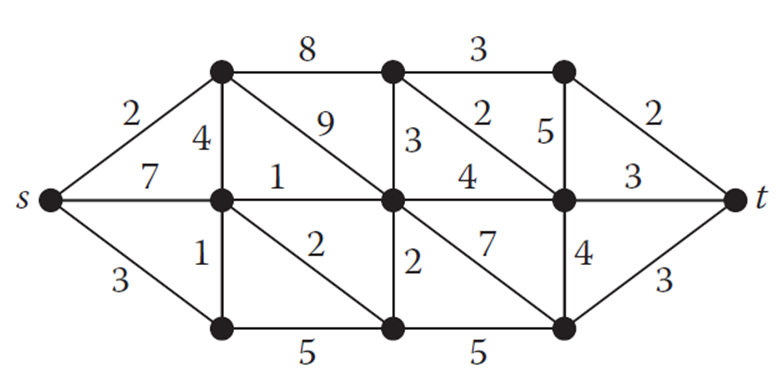

In [2]:
q1_adj_matrix = [[0, 4, 0, 8, 9, 0, 0, 0, 0, 2, 0],
                 [4, 0, 1, 0, 1, 2, 0, 0, 0, 7, 0],
                 [0, 1, 0, 0, 0, 5, 0, 0, 0, 3, 0],
                 [8, 0, 0, 0, 3, 0, 3, 2, 0, 0, 0],
                 [9, 1, 0, 3, 0, 2, 0, 4, 7, 0, 0],
                 [0, 2, 5, 0, 2, 0, 0, 0, 5, 0, 0],
                 [0, 0, 0, 3, 0, 0, 0, 5, 0, 0, 2],
                 [0, 0, 0, 2, 4, 0, 5, 0, 4, 0, 3],
                 [0, 0, 0, 0, 7, 5, 0, 4, 0, 0, 3],
                 [2, 7, 3, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 2, 3, 3, 0, 0]]
q1_node_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'S', 't']

G_q1 = nx.from_numpy_array(np.matrix(q1_adj_matrix), nodelist=q1_node_list)
q1_pos = nx.spring_layout(G_q1)

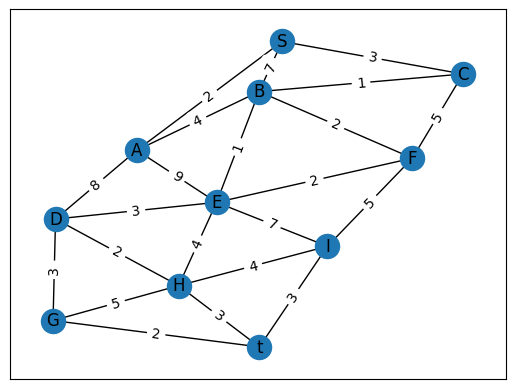

In [3]:
nx.draw_networkx(G_q1, pos=q1_pos)
nx.draw_networkx_edge_labels(G_q1, pos=q1_pos, edge_labels=nx.get_edge_attributes(G_q1, 'weight'))
plt.show()

MST cost with Kruskal: 22


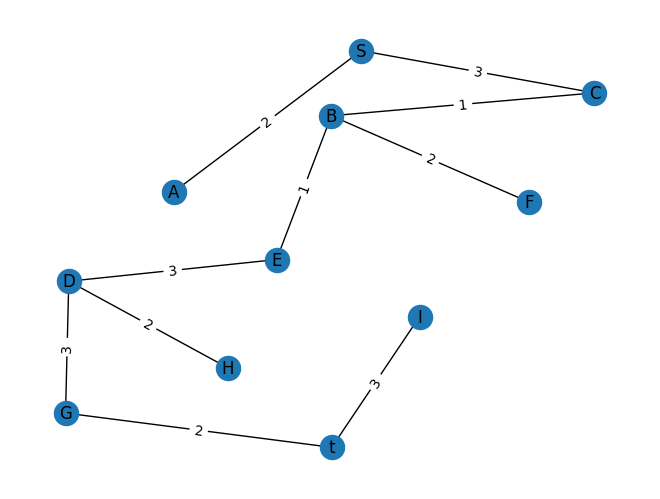

In [4]:
q1_mst = nx.minimum_spanning_tree(G_q1, algorithm='kruskal')
q1_mst_weights = nx.get_edge_attributes(q1_mst, 'weight')

print('MST cost with Kruskal:', sum(q1_mst_weights.values()))

nx.draw(q1_mst, pos=q1_pos, with_labels=True)
nx.draw_networkx_edge_labels(q1_mst, pos=q1_pos, edge_labels=q1_mst_weights)
plt.show()

## Q2 Prim

Starting Vertex: 0

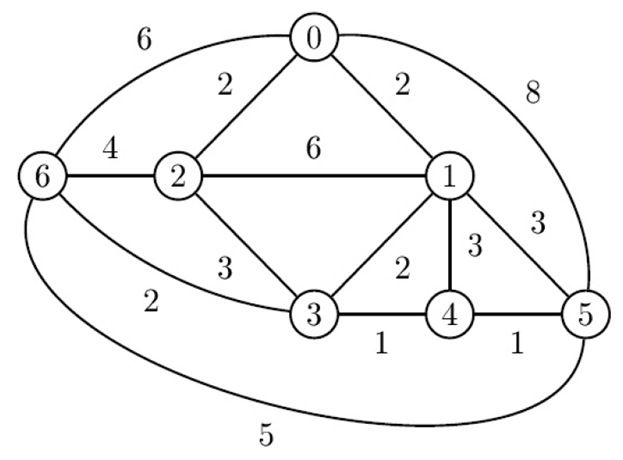

In [5]:
q2_adj_matrix = [[0, 2, 2, 0, 0, 8, 6],
                 [2, 0, 6, 2, 3, 3, 0],
                 [2, 6, 0, 3, 0, 0, 4],
                 [0, 2, 3, 0, 1, 0, 2],
                 [0, 3, 0, 1, 0, 1, 0],
                 [8, 3, 0, 0, 1, 0, 5],
                 [6, 0, 4, 2, 0, 5, 0]]
q2_node_list = ['0', '1', '2', '3', '4', '5', '6']

In [6]:
G_q2 = nx.from_numpy_array(np.matrix(q2_adj_matrix), nodelist=q2_node_list)
q2_pos = nx.spring_layout(G_q2)

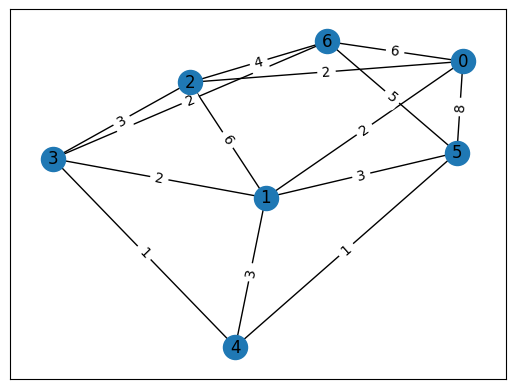

In [7]:
nx.draw_networkx(G_q2, pos=q2_pos)
nx.draw_networkx_edge_labels(G_q2, pos=q2_pos, edge_labels=nx.get_edge_attributes(G_q2, 'weight'))
plt.show()

MST cost with Prim: 10


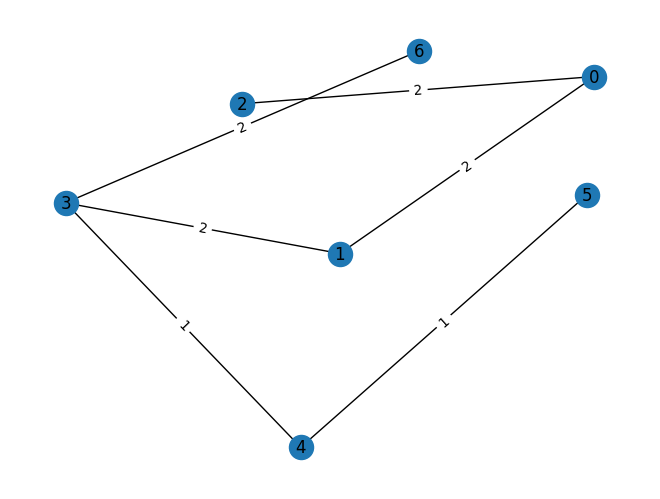

In [8]:
q2_mst = nx.minimum_spanning_tree(G_q2, algorithm='prim')
q2_mst_weights = nx.get_edge_attributes(q2_mst, 'weight')

print('MST cost with Prim:', sum(q2_mst_weights.values()))

nx.draw(q2_mst, pos=q2_pos, with_labels=True)
nx.draw_networkx_edge_labels(q2_mst, pos=q2_pos, edge_labels=q2_mst_weights)
plt.show()

## Q3

In [9]:
dist_matrix = np.loadtxt('data/ha30_dist.txt')
positions = np.loadtxt('data/ha30_xyz.txt')
with open('data/ha30_name.txt') as f:
    city_list = f.readlines()

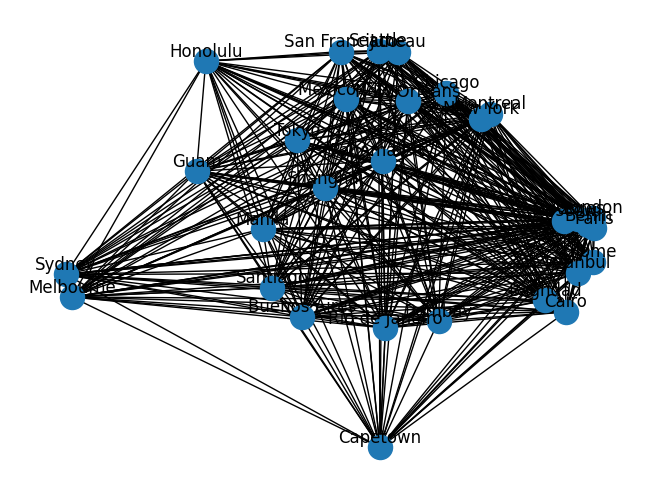

In [10]:
G_q3 = nx.Graph()
for i in range(len(city_list)):
    G_q3.add_node(city_list[i], pos=(positions[i, 0], positions[i, 1]))

for i in range(G_q3.number_of_nodes()):
    for j in range(i + 1, G_q3.number_of_nodes()):
        G_q3.add_edge(city_list[i], city_list[j], weight=dist_matrix[i][j])

pos = nx.get_node_attributes(G_q3, 'pos')
nx.draw(G_q3, pos, with_labels=True)
plt.show()

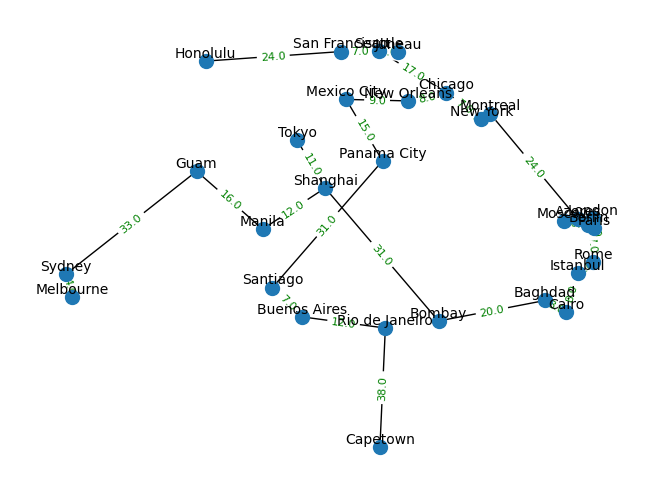

In [11]:
T = nx.minimum_spanning_tree(G_q3)

pos = nx.get_node_attributes(T, 'pos')
labels = nx.get_edge_attributes(T, 'weight')

nx.draw(T, pos=pos, with_labels=True, font_size=10, node_size=100)
nx.draw_networkx_edge_labels(T, pos=pos, edge_labels=labels, font_size=8, font_color='green')
plt.show()

In [12]:
edge_data = [
    {'source': src[:-1], 'destination': dest[:-1], 'distance': dist['weight']}
    for src, dest, dist in T.edges(data=True)
]
pd.DataFrame(edge_data)

,source,destination,distance
0,Azores,London,16.0
1,Azores,Montreal,24.0
2,Baghdad,Cairo,8.0
3,Baghdad,Bombay,20.0
4,Berlin,Paris,5.0
5,Berlin,Rome,7.0
6,Berlin,Moscow,10.0
7,Bombay,Shanghai,31.0
8,Buenos Aires,Santiago,7.0
9,Buenos Aires,Rio de Janeiro,12.0


In [13]:
print("Total", sum([T[i][j]['weight'] for (i, j) in T.edges()]))

Total 403.0


## Q4

Non-isomorphic tree count of order  7  is  11


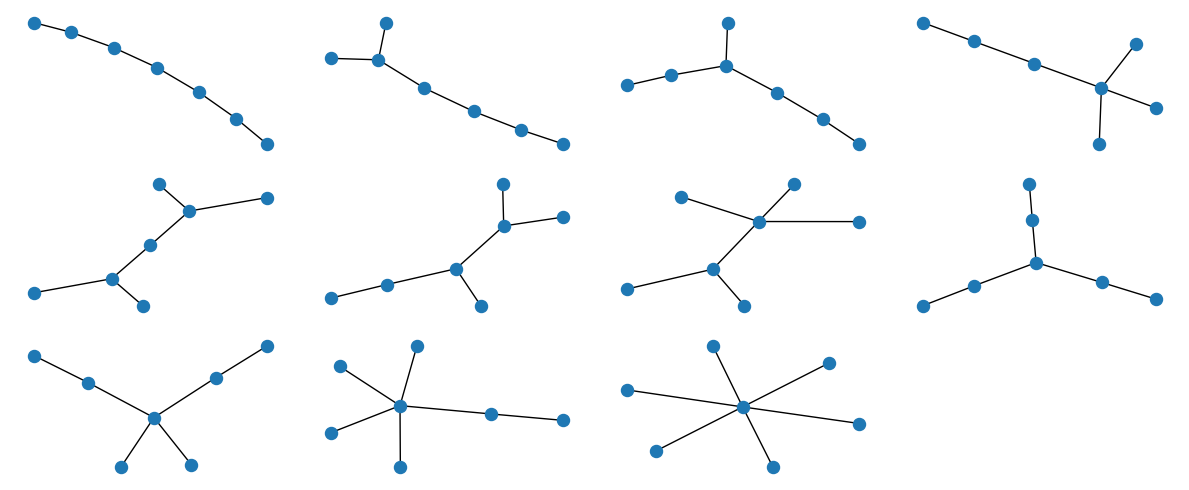

In [14]:
order = 7
GList = [G for G in nx.nonisomorphic_trees(order)]
isom_count = len(GList)
print("Non-isomorphic tree count of order ", order, " is ", isom_count)

fig, axes = plt.subplots(3, 4, figsize=(12, 5))
fig.delaxes(axes[-1, -1])
axes = axes.flat

for G, ax in zip(GList, axes):
    nx.draw(G, ax=ax, node_size=75)

plt.tight_layout()
plt.show()

## Q5